In [14]:
import os
import numpy as np
import pandas as pd

import seaborn as sns

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

<Axes: xlabel='label', ylabel='count'>

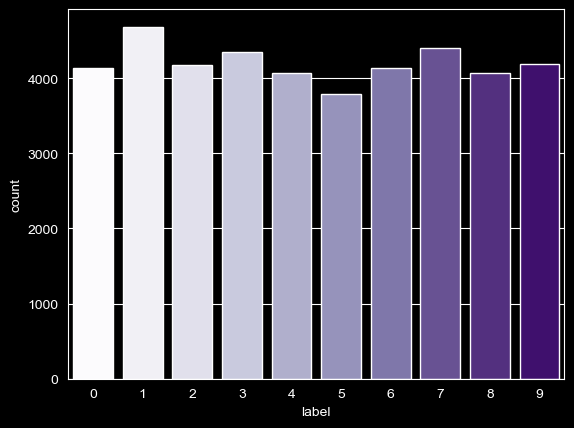

In [15]:
df = pd.read_csv("data/train.csv")

sns.countplot(
    data=df,
    x="label",
    hue="label",
    palette="Purples",
    legend=False,
)

In [16]:
# Train/validation split
y = df["label"]
X = df.drop(columns=["label"])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

# Check pixel range
print(X_test.min().min(), X_test.max().max())

0 255


In [17]:
# Normalize and create tensors
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

In [21]:
# Linear baseline: 784 -> 10
batch_size = 64
num_epochs = 100

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

model = nn.Linear(784, 10)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for _ in range(num_epochs):
    for X_batch, y_batch in train_loader:
        logits = model(X_batch)
        loss = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/linear_baseline.pt")

In [22]:
# Evaluate on held-out validation set
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

with torch.no_grad():
    logits = model(X_test_tensor)
    preds = logits.argmax(dim=1)
    accuracy = (preds == y_test_tensor).float().mean().item()
    print("Test accuracy:", accuracy)

Test accuracy: 0.9213095307350159


In [23]:
test_df = pd.read_csv("data/test.csv")
X_kaggle = test_df / 255.0
X_kaggle_tensor = torch.tensor(X_kaggle.values, dtype=torch.float32)

model.eval()
with torch.no_grad():
    logits = model(X_kaggle_tensor)
    preds = logits.argmax(dim=1).cpu().numpy()  # (28000,)

submission = pd.DataFrame(
    {
        "ImageId": np.arange(1, len(preds) + 1),
        "Label": preds,
    }
)

os.makedirs("submissions/Linear-baseline", exist_ok=True)
submission.to_csv("submissions/Linear-baseline/submission.csv", index=False)